<a href="https://colab.research.google.com/github/fatihunderpressure/githubku/blob/main/Jawaban%20Soal%20Pertemuan%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
from scipy.ndimage import label

# 1. Representasi matriks dari soal (0 = background, 1 = objek)
data = np.array([
    [0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,0,0,0,1,1,0],
    [0,1,1,1,0,0,0,1,1,0],
    [0,1,1,1,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,1,1,0,0,1,1,1,0],
    [0,0,1,1,0,0,1,1,1,0],
    [0,0,0,0,0,0,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0]
])

# 2. Definisi Struktur Konektivitas (4-connectivity)
# Struktur ini memberitahu algoritma untuk hanya melihat Atas, Bawah, Kiri, Kanan
structure_4 = [
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
]

# 3. Proses Pelabelan
labeled_array, num_features = label(data, structure=structure_4)

print(f"Matriks Hasil Labeling:\n{labeled_array}")
print("-" * 30)
print(f"Jumlah objek yang terdeteksi (4-connectivity): {num_features}")

Matriks Hasil Labeling:
[[0 0 0 0 0 0 0 0 0 0]
 [0 1 1 1 0 0 0 2 2 0]
 [0 1 1 1 0 0 0 2 2 0]
 [0 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 3 3 0 0 4 4 4 0]
 [0 0 3 3 0 0 4 4 4 0]
 [0 0 0 0 0 0 4 4 4 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]
------------------------------
Jumlah objek yang terdeteksi (4-connectivity): 4


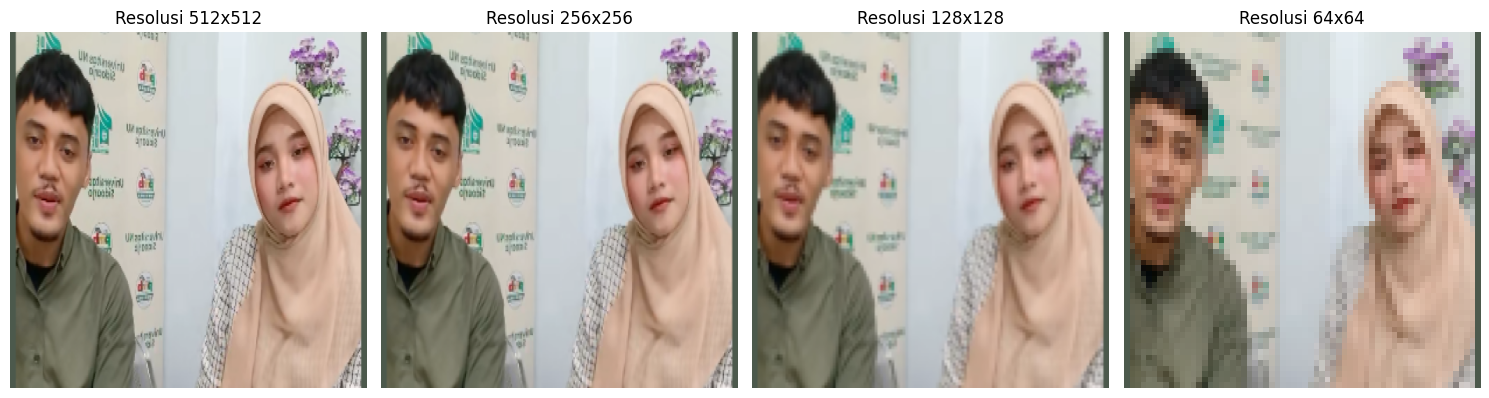

In [11]:
import cv2
import matplotlib.pyplot as plt

# 1. Baca gambar asli
# Pastikan file 'gambar_input.jpg' ada di folder yang sama dengan script ini
img = cv2.imread('GAMBAR.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Ubah ke RGB untuk Matplotlib

# 2. Daftar ukuran target (sesuai soal)
target_sizes = [512, 256, 128, 64]
results = []

# 3. Proses Resize (Sampling)
for size in target_sizes:
    # cv2.resize(gambar, (lebar, tinggi), teknik_interpolasi)
    # INTER_AREA adalah yang terbaik untuk memperkecil gambar (downsampling)
    res = cv2.resize(img_rgb, (size, size), interpolation=cv2.INTER_AREA)
    results.append(res)

# 4. Tampilkan Hasil
plt.figure(figsize=(15, 5))

for i in range(len(target_sizes)):
    plt.subplot(1, 4, i+1)
    plt.imshow(results[i])
    plt.title(f"Resolusi {target_sizes[i]}x{target_sizes[i]}")
    plt.axis('off') # Menghilangkan angka koordinat

plt.tight_layout()
plt.show()

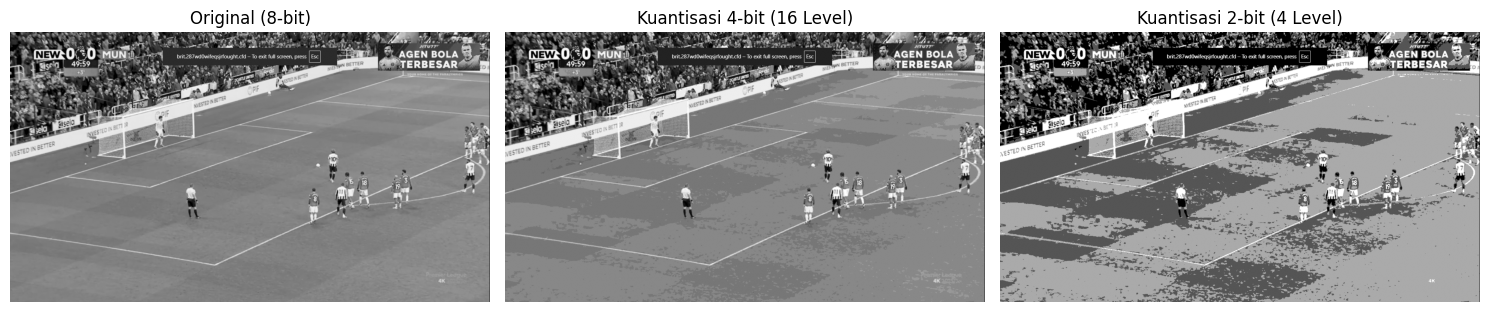

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca gambar dalam mode Grayscale (Langkah awal kuantisasi)
img_gray = cv2.imread('GAMBAR2.png', cv2.IMREAD_GRAYSCALE)

# 2. Fungsi Kuantisasi
def kuantisasi(gambar, bit):
    # Hitung jumlah level (2^bit)
    level = 2**bit

    # Tentukan lebar rentang untuk setiap level (misal 256 / 4 level = 64)
    rentang = 256 / level

    # Proses Kuantisasi:
    # Bagi nilai piksel asli dengan rentang, bulatkan, lalu kalikan kembali
    # agar nilainya tetap di skala 0-255 untuk ditampilkan.
    hasil = np.floor(gambar / rentang) * (255 / (level - 1))

    return hasil.astype(np.uint8)

# 3. Proses sesuai permintaan soal
hasil_2bit = kuantisasi(img_gray, 2)  # 4 level
hasil_4bit = kuantisasi(img_gray, 4)  # 16 level
hasil_8bit = kuantisasi(img_gray, 8)  # 256 level (asli)

# 4. Visualisasi Perbandingan
titles = ['Original (8-bit)', 'Kuantisasi 4-bit (16 Level)', 'Kuantisasi 2-bit (4 Level)']
images = [hasil_8bit, hasil_4bit, hasil_2bit]

plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()